In [ ]:
import sys
sys.path.append('../src')  # if running from notebooks/

from data_loader import load_raw_tweets, list_brands

df = load_raw_tweets('../data/raw/tweets_100k.csv')
print("Shape:", df.shape)
print(df.columns.tolist())
print(df.info())
print(df.head())

In [7]:
import os
from pathlib import Path

# If we're inside notebooks/, hop up to the project root
if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

print("CWD now:", Path.cwd())
print("Files here:", [p.name for p in Path.cwd().iterdir()][:8])

CWD now: c:\Users\hp\hiver-sde-intern
Files here: ['.env', '.git', '.gitignore', 'data', 'docs', 'golden_set', 'Makefile', 'notebooks']


In [ ]:
# Count inbound vs outbound
print(df['inbound'].value_counts())

# List top brands (by number of replies)
brand_counts = list_brands(df, min_tweets=1000)
print(brand_counts.head(20))

In [ ]:
from preprocess import extract_pairs

# Choose a brand ID from the top list
# e.g., brand_id = brand_counts.index[0]   # top brand
brand_id = "AmazonHelp" # replace with actual

pairs = extract_pairs(df, brand_id)
print(f"Number of one‑turn pairs: {len(pairs)}")
pairs.head()

In [ ]:
# Assuming you already loaded df
brand_counts = df[df['inbound'] == False]['author_id'].value_counts()
top_brand_id = brand_counts.index[0]   # e.g., 'AmazonHelp'
print("Top brand ID:", top_brand_id)

In [ ]:
import sys
from pathlib import Path

# Add the project root to sys.path so we can import from src/
project_root = Path.cwd().parent   # If you're in notebooks/ ; if you're in project root, use Path.cwd()
sys.path.append(str(project_root))

# Now you can import
from src.preprocess import extract_pairs

In [ ]:
import pandas as pd
from src.preprocess import extract_pairs

# Load your 100k sample
df = pd.read_csv('../data/raw/tweets_100k.csv')

# Quick sanity check: do any IDs match?
brand_replies_test = df[(df['inbound'] == False) & (df['author_id'] == 'AmazonHelp')]
customer_ids = brand_replies_test['in_response_to_tweet_id'].dropna().astype(str).str.strip().unique()
customer_tweets_test = df[df['inbound'] == True].copy()
customer_tweets_test['tweet_id'] = customer_tweets_test['tweet_id'].astype(str).str.strip()
matching = customer_tweets_test[customer_tweets_test['tweet_id'].isin(customer_ids)]
print(f"Number of matching customer tweets: {len(matching)}")

# Now call the function
pairs = extract_pairs(df, 'AmazonHelp')
print(f"Number of one-turn pairs: {len(pairs)}")
pairs.head()

In [ ]:
df = pd.read_csv('../data/raw/amazon_tweets_100k.csv', dtype={'tweet_id': str, 'in_response_to_tweet_id': str})

In [ ]:
import pandas as pd

# Load the new dataset with string IDs
df = pd.read_csv('../data/raw/amazon_tweets_100k.csv', dtype={'tweet_id': str, 'in_response_to_tweet_id': str})

# Quick sanity check
brand_replies = df[(df['inbound'] == False) & (df['author_id'] == 'AmazonHelp')]
customer_ids = brand_replies['in_response_to_tweet_id'].dropna().unique()
customer_tweets = df[df['inbound'] == True]
matching = customer_tweets[customer_tweets['tweet_id'].isin(customer_ids)]
print(f"Number of matching customer tweets: {len(matching)}")

# Now extract pairs using the updated function from earlier
from src.preprocess import extract_pairs
pairs = extract_pairs(df, 'AmazonHelp')
print(f"Number of one-turn pairs: {len(pairs)}")
print(pairs.head())

In [ ]:
import sys
from pathlib import Path

# Add the project root to sys.path so we can import from src/
project_root = Path.cwd().parent   # If you're in notebooks/ ; if you're in project root, use Path.cwd()
sys.path.append(str(project_root))

# Now you can import
from src.preprocess import clean_text, extract_pairs

In [29]:
with open('../src/preprocess.py', 'r') as f:
    content = f.read()
print(content)

import re
import pandas as pd

def extract_pairs(df, brand_id):
    """
    Extract one-turn pairs (customer message + brand reply) for a given brand.
    """
    df = df.copy()
    df['tweet_id'] = df['tweet_id'].astype(str).str.strip()
    df['in_response_to_tweet_id'] = df['in_response_to_tweet_id'].astype(str).str.strip()

    brand_replies = df[(df['inbound'] == False) & (df['author_id'] == brand_id)].copy()
    brand_replies = brand_replies[brand_replies['in_response_to_tweet_id'] != 'nan']
    brand_replies = brand_replies[brand_replies['in_response_to_tweet_id'] != '']

    customer_tweet_ids = brand_replies['in_response_to_tweet_id'].unique()
    customer_tweets = df[(df['inbound'] == True) & (df['tweet_id'].isin(customer_tweet_ids))].copy()

    pairs = customer_tweets.merge(
        brand_replies[['in_response_to_tweet_id', 'text', 'created_at']],
        left_on='tweet_id',
        right_on='in_response_to_tweet_id',
        how='inner',
        suffixes=('_cust', '_brand')

In [30]:
print(repr(content))

'import re\nimport pandas as pd\n\ndef extract_pairs(df, brand_id):\n    """\n    Extract one-turn pairs (customer message + brand reply) for a given brand.\n    """\n    df = df.copy()\n    df[\'tweet_id\'] = df[\'tweet_id\'].astype(str).str.strip()\n    df[\'in_response_to_tweet_id\'] = df[\'in_response_to_tweet_id\'].astype(str).str.strip()\n\n    brand_replies = df[(df[\'inbound\'] == False) & (df[\'author_id\'] == brand_id)].copy()\n    brand_replies = brand_replies[brand_replies[\'in_response_to_tweet_id\'] != \'nan\']\n    brand_replies = brand_replies[brand_replies[\'in_response_to_tweet_id\'] != \'\']\n\n    customer_tweet_ids = brand_replies[\'in_response_to_tweet_id\'].unique()\n    customer_tweets = df[(df[\'inbound\'] == True) & (df[\'tweet_id\'].isin(customer_tweet_ids))].copy()\n\n    pairs = customer_tweets.merge(\n        brand_replies[[\'in_response_to_tweet_id\', \'text\', \'created_at\']],\n        left_on=\'tweet_id\',\n        right_on=\'in_response_to_tweet_id\',

In [31]:
%reset -f


In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.preprocess import extract_pairs, clean_text
print("Import successful")

Import successful


In [3]:
import sys
from pathlib import Path
import pandas as pd

# Add project root to path (so we can import from src/)
project_root = Path.cwd().parent   # if your notebook is in 'notebooks/'
sys.path.append(str(project_root))

from src.preprocess import extract_pairs, clean_text

# 2. Load raw data (adjust path if needed)
df = pd.read_csv('../data/raw/amazon_tweets_100k.csv', dtype={'tweet_id': str, 'in_response_to_tweet_id': str})

# 3. Extract one-turn pairs
pairs = extract_pairs(df, 'AmazonHelp')
print(f"Total pairs: {len(pairs)}")

# 4. Clean the text
pairs['customer_msg_clean'] = pairs['customer_msg'].apply(clean_text)
pairs['brand_reply_clean'] = pairs['brand_reply'].apply(clean_text)
print("Cleaning complete.")

Total pairs: 6893
Cleaning complete.


In [4]:
pairs.to_csv('../data/processed/pairs_cleaned_full.csv', index=False)
print("Saved full cleaned pairs.")

Saved full cleaned pairs.


In [ ]:
import pandas as pd

sample = pd.read_csv('../data/processed/pairs_cleaned_5k.csv')
print(f"Sample size: {len(sample)}")
print(sample.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/pairs_cleaned_5k.csv'

In [2]:
import os

for root, dirs, files in os.walk('..'):   # search from one level up
    for f in files:
        if 'pairs_cleaned' in f:
            print(os.path.join(root, f))

..\data\processed\pairs_cleaned_full.csv


In [3]:
import pandas as pd

sample = pd.read_csv('../data/processed/pairs_cleaned_full.csv')
print(f"Sample size: {len(sample)}")
print(sample.columns.tolist())

Sample size: 6893
['customer_msg', 'brand_reply', 'customer_created_at', 'brand_created_at', 'customer_msg_clean', 'brand_reply_clean']


In [4]:
# Length of customer messages
sample['customer_msg_clean'].str.len().describe()

count    6850.000000
mean      107.138978
std        63.838465
min         2.000000
25%        58.000000
50%       103.000000
75%       137.000000
max       286.000000
Name: customer_msg_clean, dtype: float64

In [5]:
# How many messages are empty after cleaning?
print("Empty customer messages:", (sample['customer_msg_clean'].str.strip() == '').sum())
print("Empty brand replies:", (sample['brand_reply_clean'].str.strip() == '').sum())

# Drop empties if any
sample = sample[(sample['customer_msg_clean'].str.strip() != '') &
                (sample['brand_reply_clean'].str.strip() != '')]
print("Remaining:", len(sample))

Empty customer messages: 0
Empty brand replies: 0
Remaining: 6893


<Axes: >

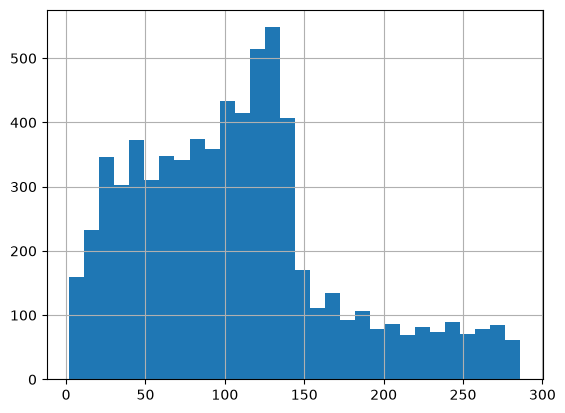

In [6]:
# Look at customer message length distribution
sample['customer_msg_clean'].str.len().hist(bins=30)

In [7]:
pd.set_option('display.max_colwidth', None)
sample[['customer_msg_clean', 'brand_reply_clean']].sample(40, random_state=42)

,customer_msg_clean,brand_reply_clean
1153,Où dois puis-je trouver votre SAV? c'est introuvable sur votre site...,Vous pouvez joindre notre SAV via le lien suivant: ^SA
6168,I know... I never have these issues with Purolator. Canada Post is terrible. There was definitely someone home when they delivered too,"Hi! We want you to have great experience with our deliveries, the only way we can improve is with your feedback. Please contact us by phone or chat: Take care! ^DA"
1582,E possibile di ricevere qualcosa nel primo di Novembre ?,Se hai già effettuato l'ordine su Amazon.it dovresti vedere la tracciabilità del pacco direttamente dal tuo account. ^MZ
2753,"Hey there. I pre-ordered Xbox One X as soon as it became available, but no indication of delivery ETA yet and need to know asap.","We'll deliver by the date listed here: If it's pending, we'll e-mail you once we have an update. ^RA"
5538,Shout out to Ashish and Shruti from online chat support resolving two order issues (one my fault) in less than a minute! Thank you!,"Glad to hear that, Kristopher! Did you receive a feedback survey at the end of your chat? ^TI"
2698,"hi, I moved homes last week, updated my address and my preorder is still going to be sent to my old address on Friday. Help!","Hi! If the order hasn't entered the dispatch process, you can change the address. More here: ^BL"
1883,I already dialed your CS team twice and as I am talking I just got the text below: what the hell is wrong with you people! I am waiting,Sorry about the hassle you've had regarding the delivery of your order. We'd like to look into it. (1/2) ^MO
5209,If I changed the delivery address now will it still be delivered today or tomorrow?,"My apologies, but Orders that have entered the dispatch process can't be modified. Please go here for more information: ^RB"
3441,"Surprised at how patronising, rude and unhelpful 's customer service is. Spent 30 minutes having my own words said back to me with no solution. Literally ""you have ordered this item"" - YES I KNOW. IT'S WHY I'M HERE.","Sorry to hear that, Dan. Without revealing any personal information, can you tell me a bit more about the issue?^TI"
3161,"3 packages, one arrived a day early, other arrived on time, last one appeared to be “on track” but then I was updated saying that it was brought back to UPS warehouse which makes no sense since they had it out for delivery.",Hi Efrain! There are many reasons why a carrier would return a parcel. You can find info here:


In [ ]:
sample[['customer_msg_clean', 'brand_reply_clean']].sample(30, random_state=7)

,customer_msg_clean,brand_reply_clean
683,Hey unpredictable delivery processes r killing Amazon experience in India. Loyal customers like me are dissatisfied. DO SOMETHING,I'm sorry for the unpleasant experience. This could be due to an incorrect tracking scan update. May I know if you 1/2 ^SH
6450,"In general words, I'll get the amount back in my bank account?","If the payment is done using credit/debit card or via net banking account, the refund will also go to the same mode of payment. ^MK"
1544,I understand shipping to Puerto Rico is now behind but orders not shipping after 2/3 weeks? Expedition taking weeks...,Apologies Siobhan. Have you been provided with revised delivery dates? ^TP
5420,Bonjour merci de ne plus utilisé Colis privé pour vos livraison,"Bonjour, rencontrez-vous un problème avec une commande en cours de livraison par colis privé?^FT"
4113,"this is what I received in box, an offer, for giving good review to product purchased. Good way to fool customers who trust reviews on your site.","Sorry for the disappointment. Believe me, this isn't what we intended. Please report the issue to our support team using this link here: and we'll have this checked. ^KA"
445,Yes. You definitely missed my delivery date. Twice. Also your call center staff seems to have no understanding of how mail delivery works.,I certainly understand your frustration! Who was the carrier for these orders? Please check here: ^BE
2969,またきた(T ^ T) これも詐欺SMSって事でいいですか？ Amazonさーん！,はい、前回ご連絡いただいたものと同様に架空請求ですので、お気を付けください。各携帯電話会社では迷惑メールの申告窓口を設置しておりますので、ご検討いただければと存じます。 YM
3545,"Merci pour votre super cadeau 😍 mes files et moi même pourront dormir sur nos deux oreilles et rêver de sable chaud et de mer translucide en toute sécurité 😍 a nous de vous rendre l’appareil, avez-vous une adresse postal afin de vous envoyer notre surprise?","Bonjour bonjour, cela nous fait énormément plaisir d'apprendre que la petite surprise vous a plu ❤️ La meilleure surprise pour nous est de savoir qu'un sourire s'est dessiné sur vos lèvres ainsi que celles de vos filles ☺️"
1837,Anyone know how you mirror on the new Amazon Fire TV? want to screen mirror #amazonfiretv #fireTV,Sure do! You can find some helpful information on screen mirroring here: I hope this helps! ^AD
561,Last mail rec'd on 09.10.2017 stating refund will be in my account by 14.10.2017 Bt same not rec'd.,That's strange. Kindly write back to the email received and we'll check this out for you. ^VM


In [9]:
from collections import Counter
import re

# Tokenize: lowercase, keep only alphabetic words of length >= 3
def tokenize(text):
    return re.findall(r'\b[a-zA-Z]{3,}\b', text.lower())

all_words = []
for msg in sample['customer_msg_clean'].dropna():
    all_words.extend(tokenize(msg))

common = Counter(all_words).most_common(50)
for word, count in common:
    print(f"{word:20s} {count}")

the                  2955
and                  1883
for                  1358
you                  1300
not                  1271
amazon               1106
have                 981
this                 951
that                 850
was                  799
but                  785
order                750
delivery             723
with                 664
your                 663
can                  632
prime                604
from                 575
now                  517
que                  509
what                 488
they                 483
been                 442
still                426
get                  421
delivered            411
just                 408
will                 402
customer             398
service              394
time                 379
are                  378
day                  366
when                 357
why                  349
how                  341
today                340
has                  337
one                  329
days               

In [10]:
def bigrams(text):
    words = tokenize(text)
    return list(zip(words, words[1:]))

all_bigrams = []
for msg in sample['customer_msg_clean'].dropna():
    all_bigrams.extend(bigrams(msg))

common_bg = Counter(all_bigrams).most_common(30)
for bg, count in common_bg:
    print(f"{bg} -> {count}")

('customer', 'service') -> 165
('for', 'the') -> 149
('can', 'you') -> 114
('has', 'been') -> 108
('thank', 'you') -> 106
('the', 'same') -> 101
('from', 'amazon') -> 101
('amazon', 'prime') -> 97
('you', 'guys') -> 95
('and', 'the') -> 86
('for', 'delivery') -> 85
('the', 'order') -> 78
('and', 'still') -> 76
('what', 'the') -> 75
('day', 'delivery') -> 74
('thanks', 'for') -> 73
('you', 'have') -> 72
('for', 'prime') -> 71
('customer', 'care') -> 68
('next', 'day') -> 64
('day', 'shipping') -> 63
('have', 'been') -> 62
('the', 'delivery') -> 61
('they', 'are') -> 60
('waiting', 'for') -> 60
('and', 'now') -> 59
('still', 'not') -> 59
('your', 'customer') -> 57
('and', 'not') -> 57
('from', 'your') -> 56


In [11]:
sample_check = sample.sample(30, random_state=99)[['customer_msg_clean']]
pd.set_option('display.max_colwidth', None)
for i, row in sample_check.iterrows():
    print(f"[{i}] {row['customer_msg_clean']}\n")

[4345] It was ripped open, have checked that everything is in there. Still doesn’t excuse the fact it’s been opened and rummaged around in AND then your really rude customer service assistants on chat telling me I’m making stuff up...

[5838] I am getting following message First, visit this page from the mobile device that needs support. Then, follow the instructions to install the SmartChk app on that device. This app saves time by finding the right team to help you. Learn more

[2433] Your amazon.in Order #402-0091077-1944373

[1787] アマゾン、コンビニ受取り出来なくなってる？

[1040] frnd ordered kindle wich was not delivered.He canceled order &amp; U agreed. Bt aftr a mnth U r denying to give refund. Disappointing

[688] why am i charged $10.99 for prime membership every month when i have purchased it for INR 499?

[5890] It was supposed to be delivered to my office by 3pm. Office is closed for the holidays now!

[2213] Hilfe? Warum läuft mein FireStick über den UK Store? 😅

[346] It's point less to act

In [12]:
pd.set_option('display.max_colwidth', None)
sample.sample(30, random_state=123)[['customer_msg_clean']]

,customer_msg_clean
6687,Sir still I didnot got my refund money please check
3850,いつも荷物が届くたびに彼は喜んで箱に飛びついてきます。深さや大きさ、入り心地がマストみたいです🐰💕これからも素敵なダンボールを送ってくれ！と申しておりました。
6518,problems with Instant Video on Xbox One currently?
925,Since how much time I wait For your action...??
1325,There was no way I could communicate that I never subscribed for a prime membership on your dot com website.
1462,"Yep! Podcasts seem to work differently from music. No option to add podcast episodes to playlist. So can’t listen on Echo, shame."
6365,yes and i have received different information each time i talk so someone and noone is making up for anything. i am now on the phone for the 4th time again about it
6070,"I am planning to get the fire HD 8"" tablet -"
2355,hi! i was sent a replacement for an item but i wanted 2 chnge the dropoff location but cant cause shipping label was sent from u guys can ya help
2173,It was supposed to be delivered today and now it's saying rescheduled due to customer request. And I have not request anything


In [13]:
pd.set_option('display.max_colwidth', None)
batch = sample.sample(40, random_state=999)[['customer_msg_clean']]
batch

,customer_msg_clean
606,"'Hey i haven't received my ""delivered"" order.' 'Did you check around your house' lmao"
1498,When you think you’ve got morrissey tickets then you get this email... What does this mean??
5531,"Den Chat gibt es gerade wohl nicht und das Telefonieren gestaltet sich momentan etwas schwierig, also hab ich es nachdem ich den Hinweis gelesen habe auch nicht weiter probiert."
6219,Acabei de comprar o Kindle 😍
6459,140円で50枚x10冊なのか？？？ ブロックで来るのか？
1995,Le dossier a l'air compliqué pour un livre qui a le nom du sport en guise de titre. N'y a-t-il pas un autre moyen de contacter le service qui gère ça ? La couverture avait été ajoutée en quelques heures donc 10 jours pour changer une catégorie...
5697,"To top it all off, I think someone stole the gift I sent via and to a friend in East Harlem."
6666,Ok sounds good thanks. Done.
6557,Por eso son los mejores ❤️
6417,merci pour votre réponse


In [2]:
import pandas as pd
from pathlib import Path

# Anchor to the project root (one level up from notebooks/)
project_root = Path.cwd().parent
golden = project_root / 'golden_set'

df = pd.read_csv(golden / 'candidates_500_prelabelled.csv')
print(df.shape)

(500, 7)


In [3]:
pd.set_option('display.max_colwidth', None)

# 1. Sample of messages the LLM labelled 'other'
print("=== 15 random 'other' messages ===")
others = df[df['llm_intent'] == 'other']['customer_msg_clean'].sample(15, random_state=42).tolist()
for m in others:
    print(" -", m[:200])   # truncate for readability

=== 15 random 'other' messages ===
 - pela amazon
 - Perfecto,, Feliz dia 😊
 - Ovviamente lettura rigorosamente su #Kindle Oasis 2017!
 - A lista é sempre grande. O que mais tá sendo vantagem são os importados. Tô de olho em 2, apesar de não ser o melhor preço, vou pela confiança que tenho na #AmazonBrasil.
 - 空き箱で遊ぶうちの子です✨
 - Yep
 - Pls call me on 9820255387
 - Being a loyal customer of ! Expecting a positive reply on this. Thank you!
 - USAs Amazon. Com
 - Vendredi 3, la veille de mon anniv :) Vous m’offrez un jeu switch ? 😝😝🙈
 - Done
 - Grazie Mille
 - Dieser Zwinker Smiley triggert mich hart *böse mit den Armen wirbel* xD
 - Grazie . Mi rendi una Santa Lucia migliore.
 - need help, anyone avl??


In [4]:
# 2. Confidence distribution
print("=== Confidence stats ===")
print(df['llm_confidence'].describe())
print("\n=== Top values ===")
print(df['llm_confidence'].value_counts().head(10))

=== Confidence stats ===
count    500.000000
mean       0.927960
std        0.056532
min        0.600000
25%        0.920000
50%        0.950000
75%        0.960000
max        1.000000
Name: llm_confidence, dtype: float64

=== Top values ===
llm_confidence
0.95    110
0.96     87
0.97     76
0.92     55
0.90     46
0.85     32
0.99     22
0.93     19
0.86     17
0.78     14
Name: count, dtype: int64


In [5]:
# 3. Overall distribution recap
print("=== Intent distribution ===")
print(df['llm_intent'].value_counts())
print("\n=== Column list ===")
print(df.columns.tolist())

=== Intent distribution ===
llm_intent
other              133
order_status       119
complaint          117
info_request        54
product_issue       24
refund_return       19
billing_payment     17
account_access      11
cancellation         6
Name: count, dtype: int64

=== Column list ===
['id', 'customer_msg', 'customer_msg_clean', 'brand_reply', 'brand_reply_clean', 'llm_intent', 'llm_confidence']


In [8]:
import pandas as pd
from pathlib import Path

df = pd.read_csv(Path('golden_set/golden_set_to_review.csv'))
print(f"Rows: {len(df)}")
print(f"Edge cases: {df['is_edge_case'].sum()}")
print(f"Columns: {df.columns.tolist()}")
print()
print("Distribution (LLM guess + edge tag):")
print(df['intent_llm_guess'].value_counts(dropna=False))
print()
print("Sample rows:")
pd.set_option('display.max_colwidth', 120)
print(df[['id', 'customer_msg_clean', 'intent_llm_guess', 'is_edge_case']].head(10))

Rows: 209
Edge cases: 54
Columns: ['id', 'customer_msg_clean', 'brand_reply_clean', 'intent_llm_guess', 'intent', 'escalation_ground_truth', 'escalation_reason', 'golden_reply', 'difficulty', 'is_edge_case', 'notes', 'edge_note']

Distribution (LLM guess + edge tag):
intent_llm_guess
NaN                54
order_status       30
complaint          25
refund_return      22
product_issue      22
billing_payment    15
account_access     15
cancellation       10
info_request        8
other               8
Name: count, dtype: int64

Sample rows:
   id  \
0   1   
1   2   
2   3   
3   4   
4   5   
5   6   
6   7   
7   8   
8   9   
9  10   

                                                                                                        customer_msg_clean  \
0                 Non bah non j’ai envoyer des feuille blanche 🤦🏽‍♂️ biensur que oui j’ai envoyer les documents demandée !   
1     Thanks. That worked. How will my Complimentary Amazon Prime membership that comes with Echo get a

In [11]:
import os
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import pandas as pd
pd.set_option('display.max_colwidth', None)

df = pd.read_csv('golden_set/golden_set_to_review.csv')

# Fill NaN with empty string so the filter works
df['intent'] = df['intent'].fillna('')

print("Total rows:", len(df))
print("Unlabelled:", (df['intent'] == '').sum())
print("Labelled so far:", (df['intent'] != '').sum())
print()

warmup = df[df['intent'] == ''].head(15)[
    ['id', 'customer_msg_clean', 'brand_reply_clean', 'intent_llm_guess']
]

for _, row in warmup.iterrows():
    print(f"--- id={row['id']} | LLM guess: {row['intent_llm_guess']}")
    print(f"CUSTOMER: {row['customer_msg_clean']}")
    print(f"BRAND:    {str(row['brand_reply_clean'])[:200]}")
    print()

Total rows: 209
Unlabelled: 209
Labelled so far: 0

--- id=35 | LLM guess: account_access
CUSTOMER: Haha! Link requires me to log in to do anything :-P Already sent an email of sorts, but thank you for trying to help. I appreciate it!
BRAND:    You can contact via this link if you don't have access: Keep us posted when you hear back to your message. Thank you. ^NV

--- id=63 | LLM guess: account_access
CUSTOMER: Dear friends, I cannot possibly sign in to my account; I have tried changing my password a bunch of times now to no avail, heeeelp!
BRAND:    I'm sorry for the trouble. We'd like to help sort this out, please contact us here: ^CO

--- id=65 | LLM guess: account_access
CUSTOMER: Hi looking for a real person to deal with an unauthorised transaction you've been dealing with for over a week? Anyone there?
BRAND:    I'm sorry for the upsetting experience Tom. Have you spoken to customer service directly via phone? If so, what information/options were provided to you about this? ^VS


In [12]:
import pandas as pd
df = pd.read_csv('golden_set/golden_set_to_review.csv')
print("Old distribution:")
print(df['intent_llm_guess'].value_counts())
print("\nNew distribution:")
print(df['intent_llm_guess_v2'].value_counts())

# Rows where they differ
diff = df[df['intent_llm_guess'] != df['intent_llm_guess_v2']]
print(f"\n{len(diff)} rows changed.")
pd.set_option('display.max_colwidth', 100)
print(diff[['customer_msg_clean', 'intent_llm_guess', 'intent_llm_guess_v2', 'llm_reason']].head(20))

Old distribution:
intent_llm_guess
order_status       30
complaint          25
product_issue      22
refund_return      22
account_access     15
billing_payment    15
cancellation       10
info_request        8
other               8
Name: count, dtype: int64

New distribution:
intent_llm_guess_v2
complaint          66
other              44
order_status       29
refund_return      24
info_request       14
product_issue      12
account_access      8
billing_payment     8
cancellation        4
Name: count, dtype: int64

124 rows changed.
                                                                                     customer_msg_clean  \
0   Haha! Link requires me to log in to do anything :-P Already sent an email of sorts, but thank yo...   
2   Hi looking for a real person to deal with an unauthorised transaction you've been dealing with f...   
4   Hey Amazon, eure neue auf 2 getrennte Bildschirme aufgeteilte Login/Passwort-Anmeldung saugt ver...   
5                      i reset 

In [1]:
python -c "import pandas as pd; df=pd.read_csv('golden_set/golden_set_to_review.csv', keep_default_na=False, na_values=['']); print('Total:', len(df)); print('Labelled:', (df['intent']!='').sum()); print(); print(df['intent'].value_counts()); print(); print(df['escalation_ground_truth'].value_counts()); print(); print(df['escalation_reason'].value_counts())"

SyntaxError: invalid syntax (3327009324.py, line 1)